# Importing Libraries

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

In [21]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    #pad_to_aspect_ratio=False,
    #data_format=None,
    #verbose=True,
)

Found 70295 files belonging to 38 classes.


## Validation Image Preprocessing

In [22]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    #pad_to_aspect_ratio=False,
    #data_format=None,
    #verbose=True,
)

Found 17572 files belonging to 38 classes.


In [23]:
for x, y in training_set.take(1):
    print(x,x.shape)
    print(y,y.shape)

tf.Tensor(
[[[[165.25 145.25 134.25]
   [169.   149.   138.  ]
   [166.5  146.5  135.5 ]
   ...
   [140.5  122.5  112.5 ]
   [157.   139.   129.  ]
   [164.5  146.5  136.5 ]]

  [[151.   131.   120.  ]
   [155.75 135.75 124.75]
   [150.25 130.25 119.25]
   ...
   [160.   142.   132.  ]
   [169.25 151.25 141.25]
   [168.25 150.25 140.25]]

  [[165.   145.   134.  ]
   [163.75 143.75 132.75]
   [154.5  134.5  123.5 ]
   ...
   [179.25 161.25 151.25]
   [159.25 141.25 131.25]
   [158.5  140.5  130.5 ]]

  ...

  [[160.75 140.75 129.75]
   [157.   137.   126.  ]
   [160.5  140.5  129.5 ]
   ...
   [182.   164.   152.  ]
   [175.75 157.75 145.75]
   [170.   152.   140.  ]]

  [[144.5  124.5  113.5 ]
   [160.   140.   129.  ]
   [159.25 139.25 128.25]
   ...
   [165.25 147.25 135.25]
   [169.75 151.75 139.75]
   [166.   148.   136.  ]]

  [[158.75 138.75 127.75]
   [171.75 151.75 140.75]
   [169.5  149.5  138.5 ]
   ...
   [191.   173.   161.  ]
   [171.75 153.75 141.75]
   [160.   142.   13

## Building Model ##


### To avoid Overshooting
1. Choose small learning rate. Default is 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neurons
3. Add more Convolution layer to extract more feature from images. There may be possibility that model unable to capture relevant features or model is confusing due to lack of features so feed with more features

In [24]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.models import Sequential


In [25]:
model = Sequential()

In [26]:
## Building Convolution Layer

model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [27]:

model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [28]:

model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [29]:

model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [30]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [31]:
model.add(Dropout(0.25)) #To avoid overfitting

In [32]:
model.add(Flatten())

In [33]:
model.add(Dense(units=1500,activation='relu'))

In [34]:
model.add(Dropout(0.40))

In [35]:
# Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model ###

In [36]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

### Model Training ###

In [38]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 146s 66ms/step - loss: 1.2422 - accuracy: 0.6336 - val_loss: 0.4478 - val_accuracy: 0.8618
Epoch 2/10
2197/2197 [==============================] - 148s 67ms/step - loss: 0.4028 - accuracy: 0.8720 - val_loss: 0.2354 - val_accuracy: 0.9250
Epoch 3/10
2197/2197 [==============================] - 143s 65ms/step - loss: 0.2405 - accuracy: 0.9211 - val_loss: 0.2322 - val_accuracy: 0.9253
Epoch 4/10
2197/2197 [==============================] - 145s 66ms/step - loss: 0.1693 - accuracy: 0.9458 - val_loss: 0.1871 - val_accuracy: 0.9382
Epoch 5/10
2197/2197 [==============================] - 143s 65ms/step - loss: 0.1248 - accuracy: 0.9595 - val_loss: 0.1304 - val_accuracy: 0.9575
Epoch 6/10
2197/2197 [==============================] - 146s 66ms/step - loss: 0.0987 - accuracy: 0.9676 - val_loss: 0.1705 - val_accuracy: 0.9497
Epoch 7/10
2197/2197 [==============================] - 148s 67ms/step - loss: 0.0805 - accuracy: 0.9737 - val_loss: 0

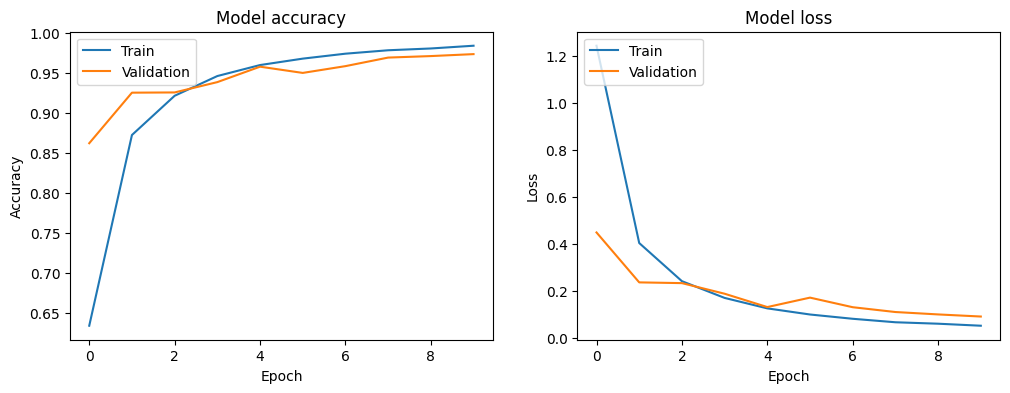

In [39]:

# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plotting training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plotting training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


## Model Evaluation ##

In [40]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

2197/2197 [==============================] - 58s 26ms/step - loss: 0.0182 - accuracy: 0.9942


In [41]:
print(train_loss, train_acc)

0.018157823011279106 0.9941674470901489


In [51]:
# Model on validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 [==============================] - 26s 45ms/step - loss: 0.0901 - accuracy: 0.9732


In [43]:
print(val_loss,val_acc)

0.09012673050165176 0.9731959700584412


### Save Model ###

In [44]:
model.save("trained_model.keras")

In [45]:
model = tf.keras.models.load_model('trained_model.keras')

In [31]:
# Recording  History
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

### Accuracy Visualization

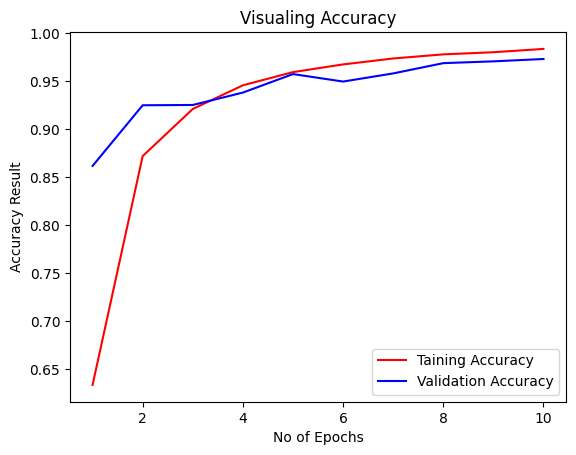

In [47]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color="red",label="Taining Accuracy")
plt.plot(epochs,training_history.history['val_accuracy'],color="blue",label="Validation Accuracy")
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualing Accuracy")
plt.legend()
plt.show()

### Some other metrics for model evaluation


In [49]:
print(train_loss, train_acc)

0.018157823011279106 0.9941674470901489


In [50]:

class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [52]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    #pad_to_aspect_ratio=False,
    #data_format=None,
    #verbose=True,
)

Found 17572 files belonging to 38 classes.


In [55]:
y_pred = model.predict(test_set)


550/550 [==============================] - 11s 20ms/step


(17572, 38)

In [56]:
y_pred, y_pred.shape

(array([[9.99999523e-01, 1.04531461e-09, 1.48199467e-10, ...,
         4.13403646e-14, 2.63516058e-15, 5.00639399e-14],
        [9.99917626e-01, 1.65315259e-06, 1.86725444e-08, ...,
         8.26018198e-10, 4.59934070e-11, 9.48551238e-10],
        [9.99999523e-01, 5.35996918e-08, 5.94335858e-10, ...,
         1.30476845e-14, 8.55792962e-14, 2.25596278e-12],
        ...,
        [8.22300339e-10, 2.38820960e-11, 3.56936624e-07, ...,
         2.56333808e-11, 1.04779518e-10, 9.99978423e-01],
        [1.44434298e-09, 3.77888736e-12, 2.21868746e-07, ...,
         1.64919495e-10, 3.71396719e-10, 9.99994755e-01],
        [3.46741047e-15, 1.61207131e-15, 5.04379741e-13, ...,
         6.39928182e-15, 1.21598250e-12, 9.99999881e-01]], dtype=float32),
 (17572, 38))

In [63]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [60]:
true_categories = tf.concat([y for x,y in test_set],axis=0)

In [61]:
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [65]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [72]:
from sklearn.metrics import classification_report,confusion_matrix


In [71]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.97      0.98       440
                                   Apple___healthy       0.97      0.97      0.97       502
                               Blueberry___healthy       0.99      0.99      0.99       454
          Cherry_(including_sour)___Powdery_mildew       0.98      1.00      0.99       421
                 Cherry_(including_sour)___healthy       0.97      1.00      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.97      0.92       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.92      0.

In [73]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[492,   0,   0, ...,   0,   0,   0],
       [  2, 489,   0, ...,   0,   0,   0],
       [  0,   0, 428, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 484,   0,   0],
       [  0,   0,   0, ...,   0, 441,   0],
       [  0,   0,   0, ...,   0,   0, 474]], dtype=int64)

### Confusion Matrix Visualisation

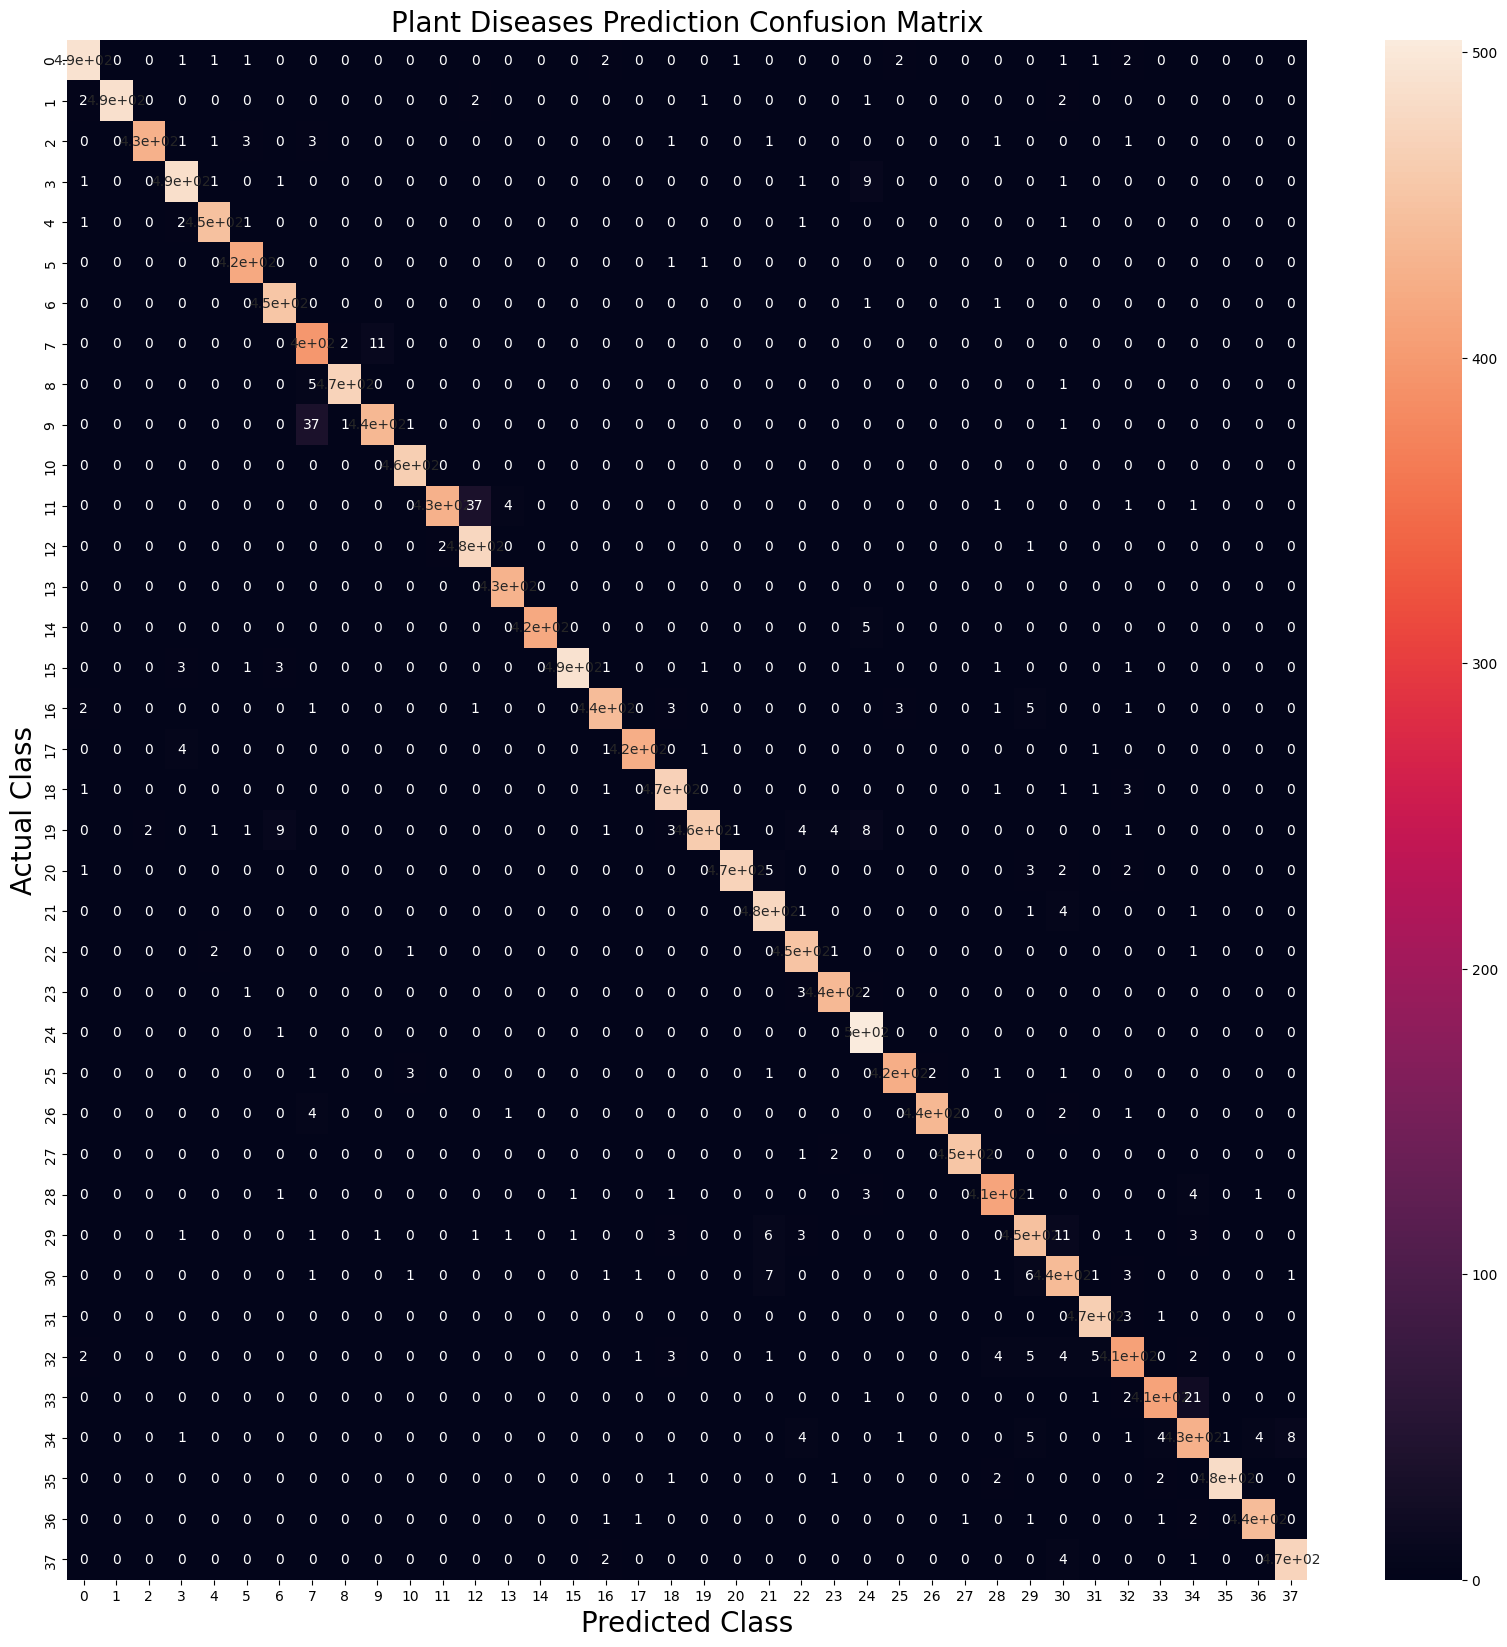

In [87]:
plt.figure(figsize=(20,20))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Diseases Prediction Confusion Matrix",fontsize=20)
plt.show()